In [1]:
import pandas as pd
import numpy as np

# Load Kaggle Datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1458644, 11)
Test shape: (625134, 9)


In [3]:
# Convert strings to datetime objects
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])
train_df['dropoff_datetime'] = pd.to_datetime(train_df['dropoff_datetime'])
test_df['pickup_datetime'] = pd.to_datetime(test_df['pickup_datetime'])

# Remove outliers & invalid durations
train_df = train_df[(train_df['trip_duration'] > 0) & (train_df['trip_duration'] < 86400)]

# Drop missing values
train_df = train_df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])
test_df = test_df.dropna(subset=['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude'])

In [4]:
print("Cleaned Train shape:", train_df.shape)
print("Cleaned Test shape:", test_df.shape)

Cleaned Train shape: (1458640, 11)
Cleaned Test shape: (625134, 9)


In [5]:
# Function to calculate distance between pickup and dropoff coordinates
def haversine_array(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # in kilometers
    lat = lat2 - lat1
    lng = lng2 - lng1
    d = np.sin(lat * 0.5)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng * 0.5)**2
    h = 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

In [6]:
# Extract features (Hour, Day of week, Weekend, Distance)
def extract_features(df):
    df['pickup_hour'] = df['pickup_datetime'].dt.hour
    df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
    df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    
    df['distance_km'] = haversine_array(
        df['pickup_latitude'].values, 
        df['pickup_longitude'].values, 
        df['dropoff_latitude'].values, 
        df['dropoff_longitude'].values
    )
    return df

# Apply features to both train and test data
train_df = extract_features(train_df)
test_df = extract_features(test_df)

# Display first 5 rows of train_df to check new columns
train_df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,is_weekend,distance_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,1,1.188588


In [7]:
# Extract detailed temporal features for Train Dataset
train_df['pickup_month'] = train_df['pickup_datetime'].dt.month
train_df['pickup_day'] = train_df['pickup_datetime'].dt.day
train_df['pickup_hour'] = train_df['pickup_datetime'].dt.hour
train_df['pickup_minute'] = train_df['pickup_datetime'].dt.minute
train_df['pickup_dayofweek'] = train_df['pickup_datetime'].dt.dayofweek
train_df['is_weekend'] = train_df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

# Define Rush Hour / Peak Hours (Morning 8-10 AM, Evening 5-7 PM)
train_df['is_peak_hour'] = train_df['pickup_hour'].apply(lambda h: 1 if (8 <= h <= 10) or (17 <= h <= 19) else 0)

# Extract detailed temporal features for Test Dataset
test_df['pickup_month'] = test_df['pickup_datetime'].dt.month
test_df['pickup_day'] = test_df['pickup_datetime'].dt.day
test_df['pickup_hour'] = test_df['pickup_datetime'].dt.hour
test_df['pickup_minute'] = test_df['pickup_datetime'].dt.minute
test_df['pickup_dayofweek'] = test_df['pickup_datetime'].dt.dayofweek
test_df['is_weekend'] = test_df['pickup_dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
test_df['is_peak_hour'] = test_df['pickup_hour'].apply(lambda h: 1 if (8 <= h <= 10) or (17 <= h <= 19) else 0)

print("Time features added successfully.")

Time features added successfully.


In [8]:
# Absolute Latitude and Longitude Differences
train_df['lat_diff'] = (train_df['dropoff_latitude'] - train_df['pickup_latitude']).abs()
train_df['lon_diff'] = (train_df['dropoff_longitude'] - train_df['pickup_longitude']).abs()

test_df['lat_diff'] = (test_df['dropoff_latitude'] - test_df['pickup_latitude']).abs()
test_df['lon_diff'] = (test_df['dropoff_longitude'] - test_df['pickup_longitude']).abs()

# Manhattan Distance Calculation (Approximate metric distance for grid-like cities)
def manhattan_distance(lat1, lng1, lat2, lng2):
    # Approximation: 1 degree latitude ~ 111 km, 1 degree longitude ~ 85 km in NYC
    lat_dist = np.abs(lat2 - lat1) * 111
    lng_dist = np.abs(lng2 - lng1) * 85
    return lat_dist + lng_dist

train_df['distance_manhattan_km'] = manhattan_distance(
    train_df['pickup_latitude'], train_df['pickup_longitude'],
    train_df['dropoff_latitude'], train_df['dropoff_longitude']
)

test_df['distance_manhattan_km'] = manhattan_distance(
    test_df['pickup_latitude'], test_df['pickup_longitude'],
    test_df['dropoff_latitude'], test_df['dropoff_longitude']
)

print("Distance & Spatial features added successfully.")

Distance & Spatial features added successfully.


In [9]:
# Calculate Average Speed for Train Dataset (in km/h)
train_df['speed_kmh'] = (train_df['distance_km'] / (train_df['trip_duration'] / 3600))

# Filter out unrealistically fast (> 120 km/h) or extremely slow (< 1 km/h for long trips) rows
train_df = train_df[(train_df['speed_kmh'] <= 120) & (train_df['speed_kmh'] >= 0.5)]

print("Cleaned Train Shape after Speed Filtering:", train_df.shape)
train_df[['trip_duration', 'distance_km', 'distance_manhattan_km', 'speed_kmh', 'is_peak_hour']].head()

Cleaned Train Shape after Speed Filtering: (1447153, 23)


,trip_duration,distance_km,distance_manhattan_km,speed_kmh,is_peak_hour
0,455,1.498521,1.748741,11.856428,1
1,663,1.805507,2.443325,9.803659,0
2,2124,6.385098,8.213604,10.822201,0
3,429,1.485498,1.660362,12.465721,1
4,435,1.188588,1.197479,9.836594,0


In [10]:
# Save the engineered dataset into CSV format
train_df.to_csv('processed_train.csv', index=False)
test_df.to_csv('processed_test.csv', index=False)

print("Processed train and test datasets saved successfully.")

Processed train and test datasets saved successfully.


--- M2 Data Summary ---
Total Features Extracted: 25
Final Cleaned Train Rows: 1447153
Final Cleaned Test Rows: 625134


C:\Users\gadde\AppData\Local\Temp\ipykernel_28472\2110504233.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=train_df, x='pickup_hour', y='trip_duration', estimator='median', ci=None, color='blue')


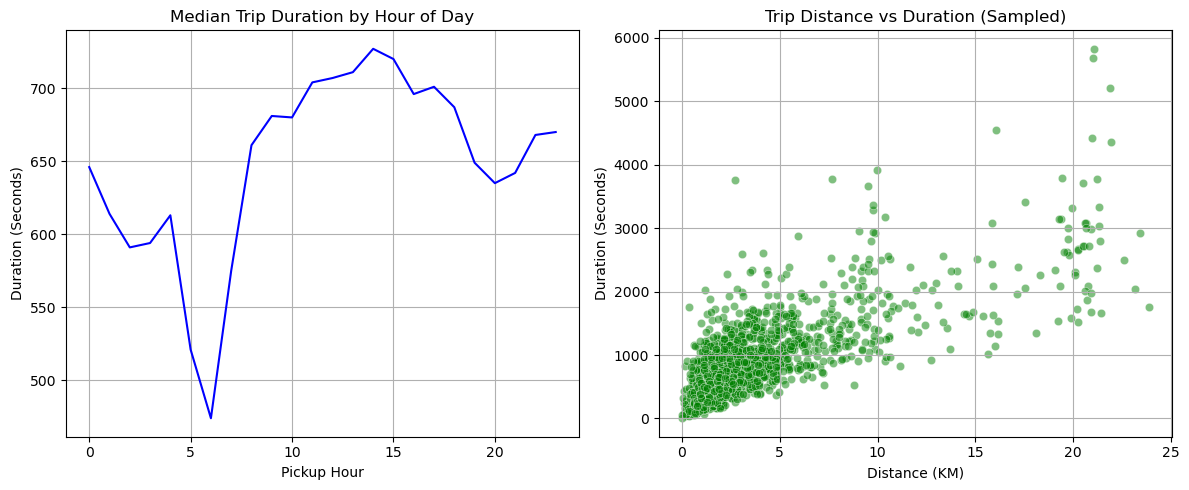

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cyclic Transformations for Hours and Months
train_df['hour_sin'] = np.sin(2 * np.pi * train_df['pickup_hour'] / 24.0)
train_df['hour_cos'] = np.cos(2 * np.pi * train_df['pickup_hour'] / 24.0)

test_df['hour_sin'] = np.sin(2 * np.pi * test_df['pickup_hour'] / 24.0)
test_df['hour_cos'] = np.cos(2 * np.pi * test_df['pickup_hour'] / 24.0)

# 2. Data Summary & Validation
print("--- M2 Data Summary ---")
print(f"Total Features Extracted: {train_df.shape[1]}")
print(f"Final Cleaned Train Rows: {train_df.shape[0]}")
print(f"Final Cleaned Test Rows: {test_df.shape[0]}")

# 3. Visualizing Key Insights (EDA Charts)
plt.figure(figsize=(12, 5))

# Chart 1: Trip Duration vs Pickup Hour
plt.subplot(1, 2, 1)
sns.lineplot(data=train_df, x='pickup_hour', y='trip_duration', estimator='median', ci=None, color='blue')
plt.title('Median Trip Duration by Hour of Day')
plt.xlabel('Pickup Hour')
plt.ylabel('Duration (Seconds)')
plt.grid(True)

# Chart 2: Distance vs Trip Duration Correlation
plt.subplot(1, 2, 2)
sns.scatterplot(data=train_df.sample(2000), x='distance_km', y='trip_duration', alpha=0.5, color='green')
plt.title('Trip Distance vs Duration (Sampled)')
plt.xlabel('Distance (KM)')
plt.ylabel('Duration (Seconds)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. K-Means Clustering for Popular Location Zones
coords = np.vstack([
    train_df[['pickup_latitude', 'pickup_longitude']].values,
    train_df[['dropoff_latitude', 'dropoff_longitude']].values
])

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(coords[::100])

train_df['pickup_cluster'] = kmeans.predict(train_df[['pickup_latitude', 'pickup_longitude']].values)
train_df['dropoff_cluster'] = kmeans.predict(train_df[['dropoff_latitude', 'dropoff_longitude']].values)

test_df['pickup_cluster'] = kmeans.predict(test_df[['pickup_latitude', 'pickup_longitude']].values)
test_df['dropoff_cluster'] = kmeans.predict(test_df[['dropoff_latitude', 'dropoff_longitude']].values)

# 2. PCA Transformation for Spatial Orientation
pca = PCA(n_components=2, random_state=42)
pca.fit(train_df[['pickup_latitude', 'pickup_longitude']].values)

train_df['pca_num_1'] = pca.transform(train_df[['pickup_latitude', 'pickup_longitude']].values)[:, 0]
train_df['pca_num_2'] = pca.transform(train_df[['pickup_latitude', 'pickup_longitude']].values)[:, 1]

test_df['pca_num_1'] = pca.transform(test_df[['pickup_latitude', 'pickup_longitude']].values)[:, 0]
test_df['pca_num_2'] = pca.transform(test_df[['pickup_latitude', 'pickup_longitude']].values)[:, 1]

print("Advanced Spatial & Cluster Features Added Successfully.")

Advanced Spatial & Cluster Features Added Successfully.


In [14]:
# Re-save the complete engineered dataset into CSV format
train_df.to_csv('processed_train.csv', index=False)
test_df.to_csv('processed_test.csv', index=False)

print("Final Processed Datasets Saved Successfully!")
print(f"Total Columns in Processed Train: {train_df.shape[1]}")

Final Processed Datasets Saved Successfully!
Total Columns in Processed Train: 29
